In [1]:
#!python3 -m jupyter kernelspec install-self
print('Hello World')

##Test case to make sure Jupyter is running

Hello World


In [20]:
#!pip install openpyxl
#!mamba install pandas
#!mamba install scikit-learn
#!mamba install seaborn
#!mamba install warnings
#!mamba install matplotlib
##^ install block
##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from sklearn.cluster import KMeans
##^ import block
##
wr.filterwarnings('ignore')

pd.options.display.float_format = '{:20,.2f}'.format
##^Allows the reception percentages to be percentages
df = pd.read_excel('Data Mining Movie Set.xlsx')
print(df.head())
##^reads dataset built from list of highest grossing and best recieved movies
#df.shape()
df.info()
df.describe().T
df.columns.tolist()
##^Base analysis
#df.nunique()
#df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates()
##^Removes films with missing data or films that appear on both sources
#df.describe()
##The final dataset contains 411 entities. The average film makes a profit of 519 million dollars, has a critical rating of 83%, and an audience score of 87%. The standard deviantion between reception is quite small, 
##showing a link between popularity and profitability. Note that the general public has less variety than professional critics. However, the standard deviation of the box office shows otherwise. There is about 507 million dollars
##worth of variency in the dataset, ranging from the low millions to just over a billion dollar profit. Perhaps the reason why the variety in opinions and the variety in profit are so different is in how reviews are calculated. If 9 out of
##10 critics approve the film, then it has a 90% critical response. This happens for films with hundreds of reviews as well as films who only get 10 critics. The quartiles paint a similar picture. While Q2 has a $482 million box office and
##a 91% audience reception, Q3 has nearly double the box office yet a 3% increse in audience scores. 

          Film Name  Worldwide Box Office    Critical Response  \
0              1917        446,064,352.00                 0.88   
1              2012        791,217,826.00                 0.40   
2      12 Angry Men              9,844.00                 1.00   
3  12 Years a Slave        187,734,091.00                 0.95   
4         12th Fail            138,288.00                 0.91   

     Audience Response  Year of Release  
0                 0.88             2019  
1                 0.47             2009  
2                 0.97             1957  
3                 0.90             2013  
4                 0.97             2023  
<class 'pandas.DataFrame'>
RangeIndex: 447 entries, 0 to 446
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Film Name             447 non-null    object 
 1   Worldwide Box Office  444 non-null    float64
 2   Critical Response     443 non-null    float64
 3 

In [21]:
df.describe()

,Worldwide Box Office,Critical Response,Audience Response,Year of Release
count,411.00,411.00,411.00,411.00
mean,"519,749,158.78",0.83,0.87,"1,998.90"
std,"507,047,335.53",0.17,0.12,23.99
min,399.00,0.18,0.41,"1,921.00"
25%,"33,007,748.00",0.77,0.84,"1,989.50"
50%,"482,352,390.00",0.90,0.91,"2,008.00"
75%,"830,237,770.50",0.94,0.94,"2,016.00"
max,"2,923,710,708.00",1.00,1.00,"2,025.00"


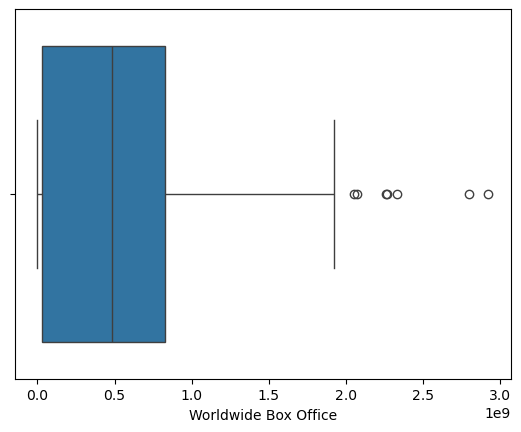

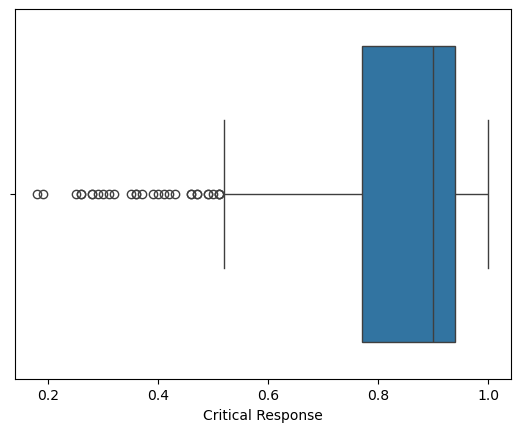

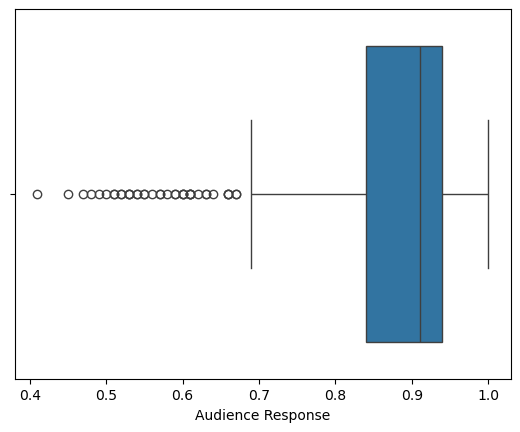

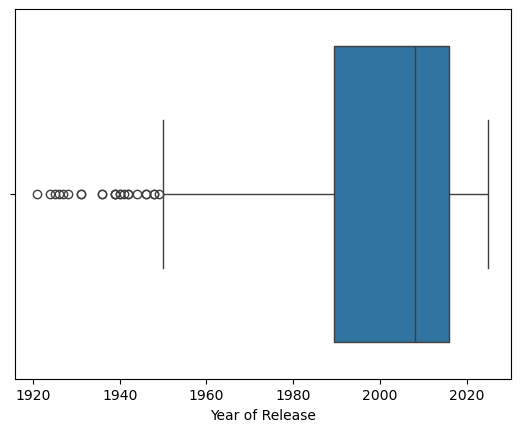

In [22]:
dm = sns.boxplot(x=df['Worldwide Box Office'])
plt.show()
dm = sns.boxplot(x=df['Critical Response'])
plt.show()
dm = sns.boxplot(x=df['Audience Response'])
plt.show()
dm = sns.boxplot(x=df['Year of Release'])
plt.show()
##Box Office has its quartiles below a billion dollar profit (as per the mean) and ends at around 1.8 billion dollars. The few outliers shown are for films with more than 2 billion in profit. 
##Looking at the raw data, most of these points are Avengers films. Both responses are clustered around positive reviews (80% to 90%) with a negative skew. 
##Due to critics having higher standards and varied tastes, their plot strecthes down to 50%. Audiences are driven more by personal feelings which means a smaller range. 
##However, audiences have more single responses and outliers compared to critics
##The box for release year starts around 1990 while the plot extends back to the 50s, matchin up with the popularity of movies during those eras.

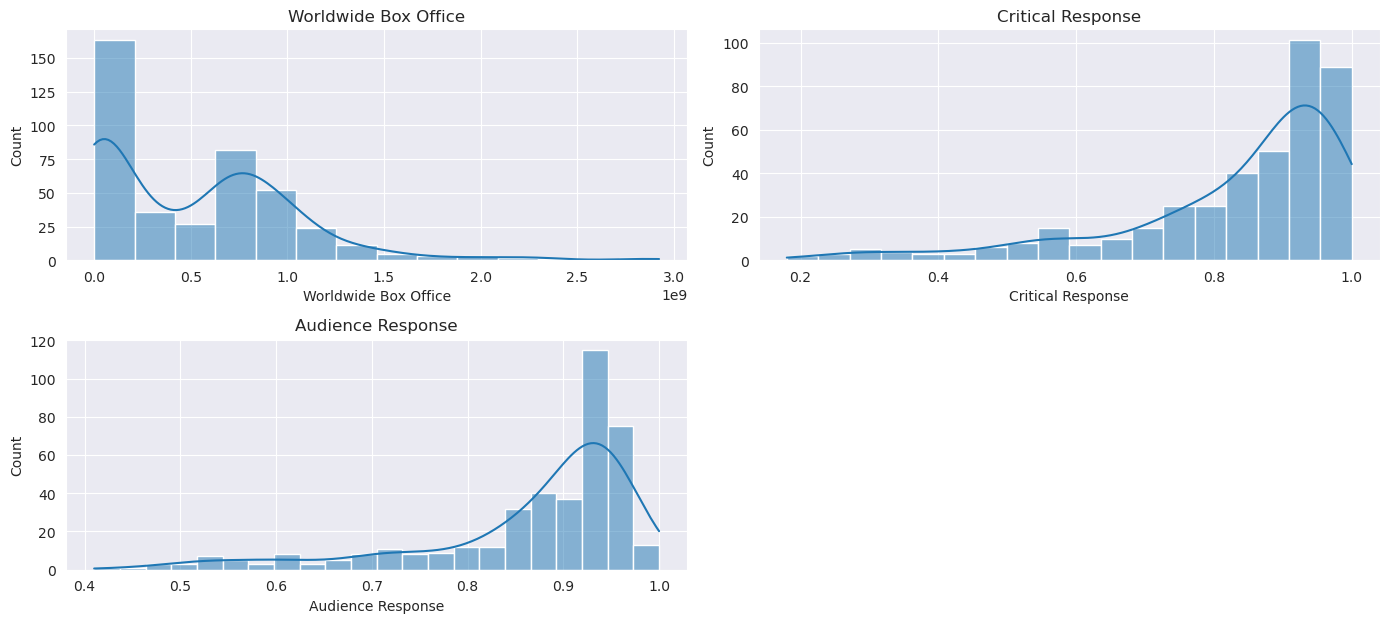

In [23]:
#fig = plt.figure(figsize = (10, 10))
sns.set_style("darkgrid")

float_columns = df.select_dtypes(include=["float64"]).columns
plt.figure(figsize=(14, len(float_columns) * 3))
for idx, feature in enumerate(float_columns, 1):
    plt.subplot(len(float_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature}")
plt.tight_layout()
plt.show()
##Responses have a heavy preference towards positivity. However, audiences and critics do have some unique qualities. The critics believe in the idea of a perfect movie more than the audiences as seen in the higher count of  ~90% and 
##the drop at 100% seen in the latter graph. There is a bump around 54% in the critical response graph for devisive films while the audience reaction graph has a flatter bar for bad films. Speaking of the shape, the critical response
##graph rises faster than the audience graph because the amount of professional views are more spread out across the scores. 

##As for the Box office graph, it's quantified in the billions so the two peaks are built from the movies which didn't even crack into the millions and the enstallments of famous franchises. 

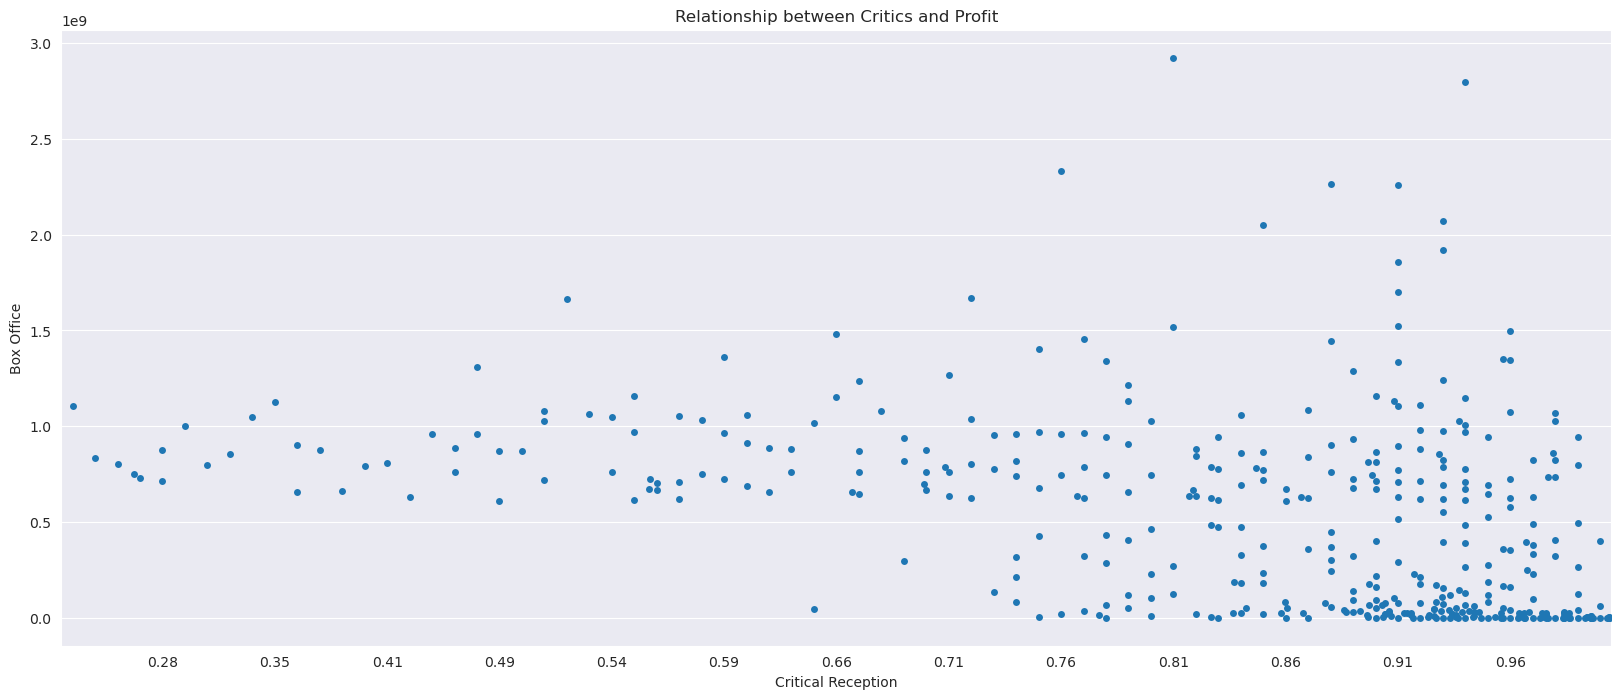

In [24]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Critical Response", y="Worldwide Box Office", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5]) #This one part was kicking my ass
plt.title('Relationship between Critics and Profit')
plt.xlabel('Critical Reception')
plt.ylabel('Box Office')
plt.show()
##An 800 million dollar profit seems to be a universal standard for films regardless of how it was reviewed. The massive clump of highly praised but low profit films could be a sign of small demographics, 
##or it could be caused by the way ratings or profits are calculated

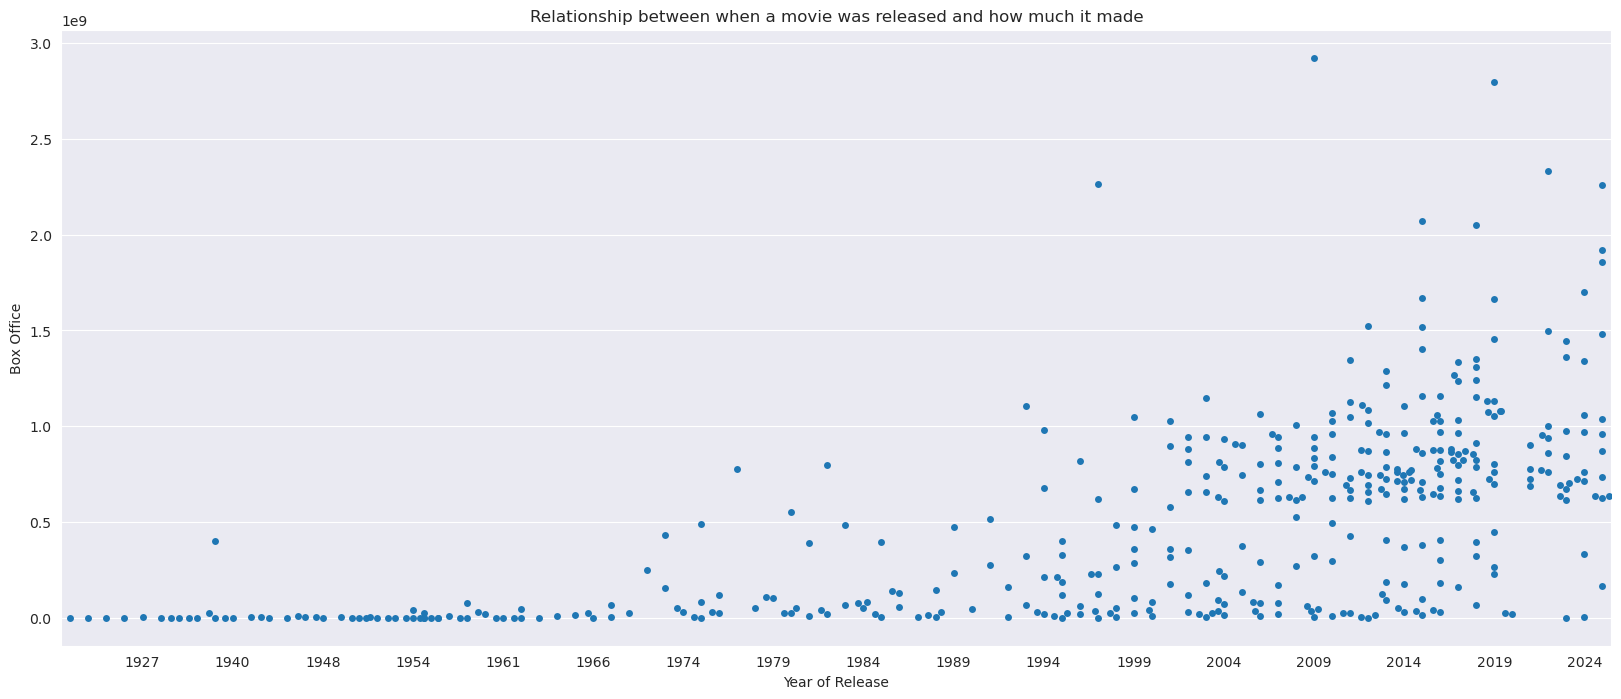

In [25]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Year of Release", y="Worldwide Box Office", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
plt.title('Relationship between when a movie was released and how much it made')
plt.xlabel('Year of Release')
plt.ylabel('Box Office')
plt.show()
##Before the 1970s, films were expected to make less than 100 milion dollars in profit. However, as certain films started making more money, some 'waves' begin to form. This created the new baseline in the early 2000s, where 
##a billion dollar profit (give or take) was expected for major movies. The original baseline still exists but has expanded to films that made up to 300 million. Meanwhile, extremely marketed films have reached 1.5 billion and rising.

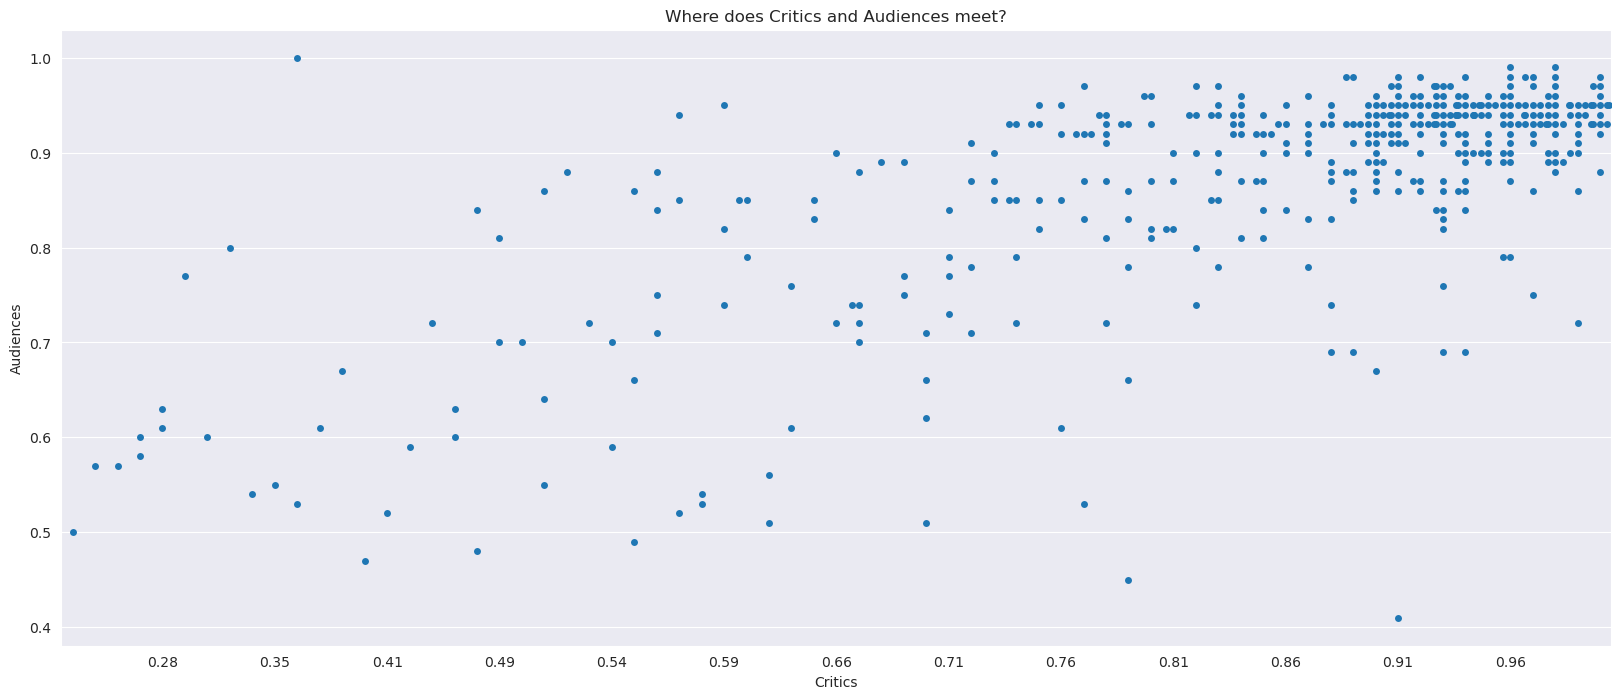

In [26]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Critical Response", y="Audience Response", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
plt.title('Where does Critics and Audiences meet?')
plt.xlabel('Critics')
plt.ylabel('Audiences')
plt.show()
##Strange lack of "Pretensious" films that are loved by critics but hated by audiences. Main clump are "the perfect movie". Secondary clump are films that audiences enjoyed as is but critics had issues with. This clump covers a much wider
##scope from 86% critical response to 66%

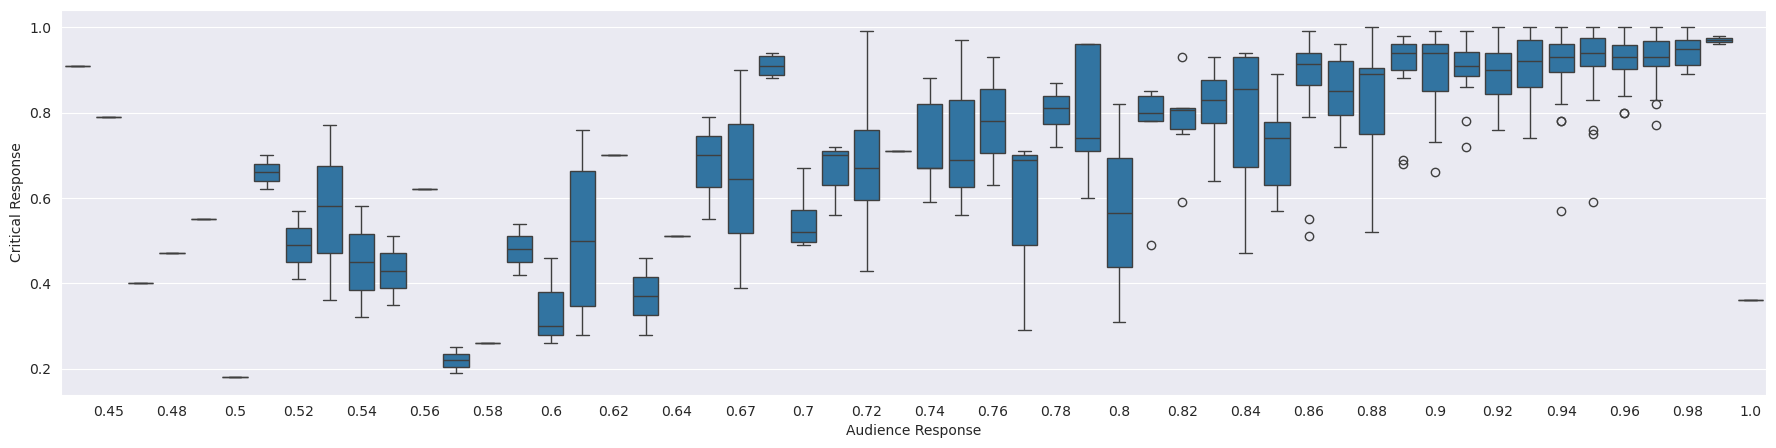

In [27]:
plt.figure(figsize=(22,5))
dm = sns.boxplot(data=df,x="Audience Response",y="Critical Response")
ticks = dm.get_xticks()
dm.set_xticks(ticks[1::2])
plt.show()
##Responses towards films become more varied the worse the audience score becomes. Based on the clusters, this is caused by films with a wider target audience (Cluster 3) attracting people who didn't like it while films with
##specific audiences (Cluster 2) only attract those who love it unconditionally. That being said, very popular films might get so much reviews from general watchers and professionals that the negativity doesn't have much of an impact, 
##as shown in Cluster 1.

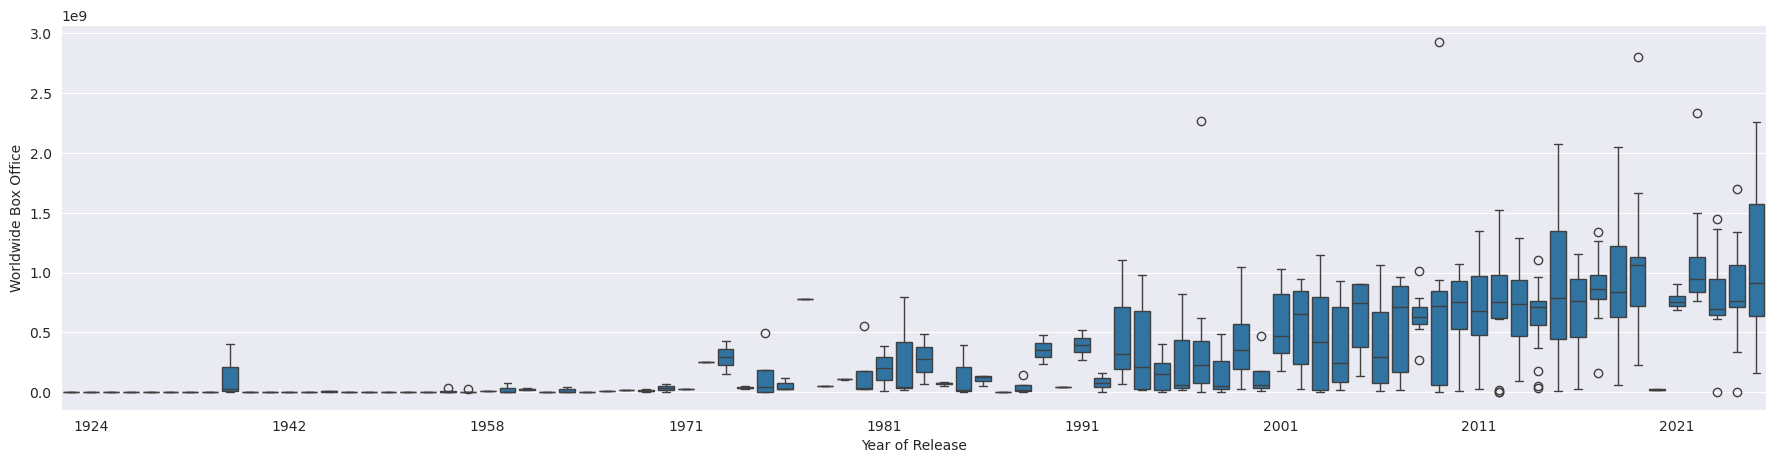

In [28]:
plt.figure(figsize=(22,5))
dm = sns.boxplot(data=df,x="Year of Release",y="Worldwide Box Office")
ticks = dm.get_xticks()
dm.set_xticks(ticks[1::10])
plt.show()
##Much more activity starting in the late 70s before rising in the 90s. The former is the start of the blockbuster and the latter is the rise of the blockbuster

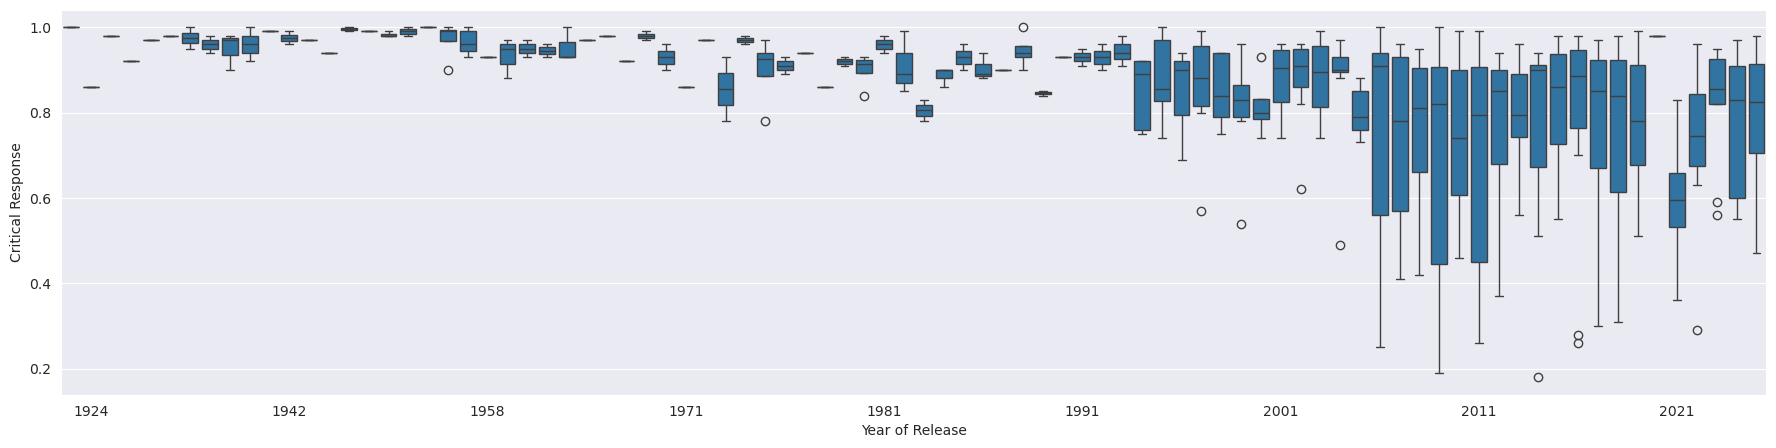

In [36]:
plt.figure(figsize=(22,5))
dm = sns.boxplot(data=df,x="Year of Release",y="Critical Response")
ticks = dm.get_xticks()
dm.set_xticks(ticks[1::10])
plt.show()
##the worse responses are more common in the last 20 or so years, mainly thanks to box office hits that apeal to such a wide audience that nothing sticks
##while older movies are drenched in a specific culture/era/idea which sticks in the minds of the viewer and ends up inspiring them to either make new
##movies or watch similar films. This is basically why franchises exist.

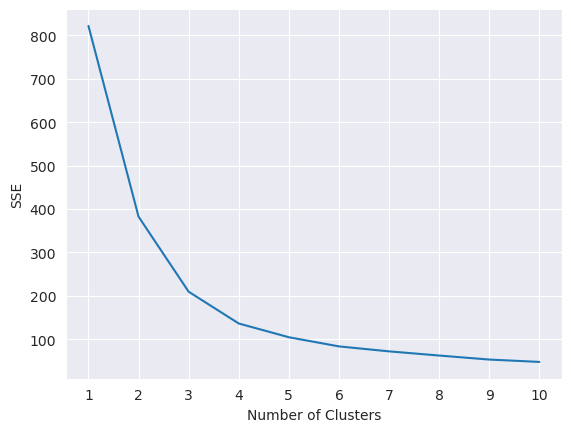

            Film Name  Worldwide Box Office    Critical Response  \
3    12 Years a Slave        187,734,091.00                 0.95   
4           12th Fail            138,288.00                 0.91   
6            3 Idiots         60,262,836.00                 1.00   
7    A Beautiful Mind        316,791,257.00                 0.74   
10       A Separation         22,926,076.00                 0.99   
..                ...                   ...                  ...   
428    V for Vendetta        134,686,457.00                 0.73   
432           Warrior         23,308,615.00                 0.84   
434          Whiplash         50,431,161.00                 0.94   
437        Wild Tales         31,478,893.00                 0.94   
444         Your Name        405,320,132.00                 0.98   

       Audience Response  Year of Release  cluster  
3                   0.90             2013        0  
4                   0.97             2023        0  
6                   0.93

In [42]:
from sklearn.preprocessing import StandardScaler
df = df.dropna()
data = df.iloc[: , [1,4]].values
scaled_df = StandardScaler().fit_transform(data)
#print(scaled_df[:5])
##make sure it works

kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()
##
kmeans = KMeans(init="random", n_clusters=4, n_init=10, random_state=1)
##reviews 4 clusters 10 times
#fit k-means algorithm to data
kmeans.fit(scaled_df)

#view cluster assignments for each observation
kmeans.labels_

df['cluster'] = kmeans.labels_

#view updated DataFrame
print(df[df['cluster'] == 0])
print(df[df['cluster'] == 1])
print(df[df['cluster'] == 2])
print(df[df['cluster'] == 3])

[[8.28203246e+07 9.16410256e-01]
 [1.12239452e+09 7.42727273e-01]
 [7.09200731e+08 7.48550725e-01]
 [2.12660012e+09 8.39166667e-01]]


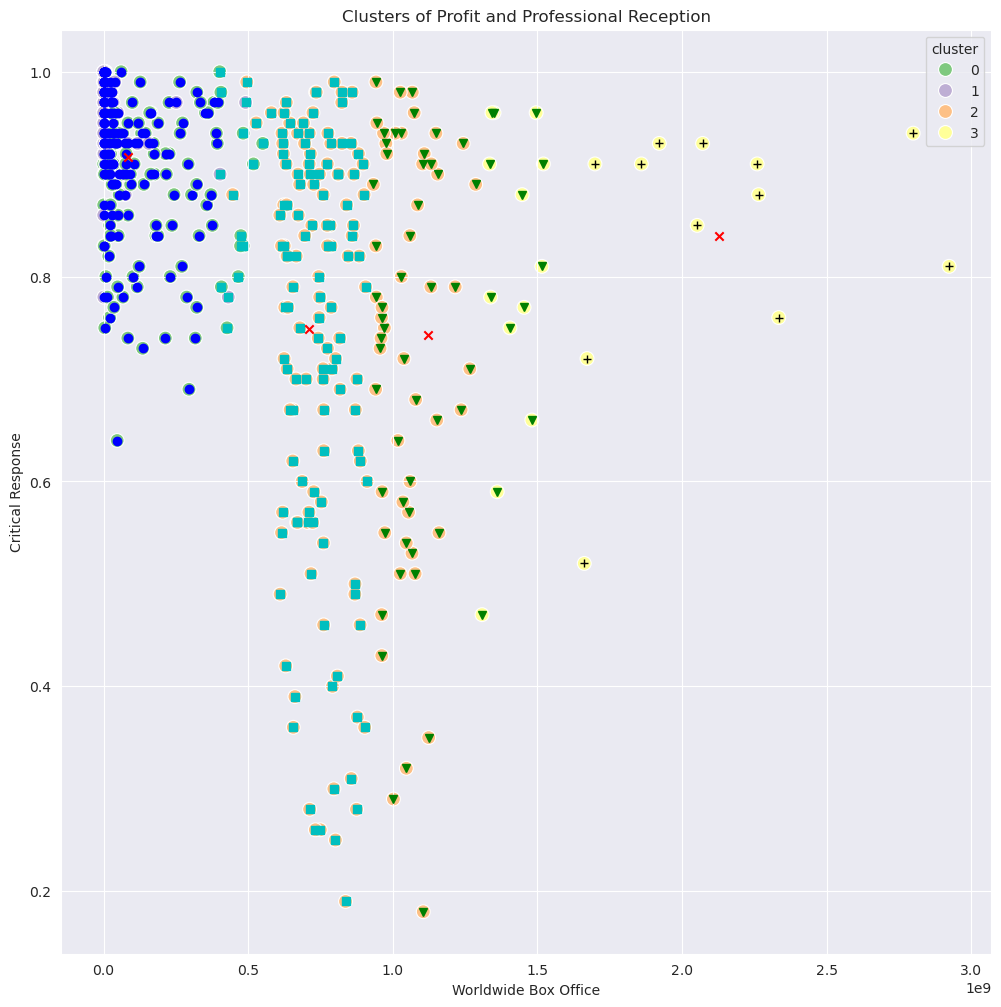

In [30]:
x1 = np.array(df['Worldwide Box Office'])
x2 = np.array(df['Critical Response'])
plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of Profit and Professional Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None', zorder = 5) ##overlaid on scatter plot

sns.scatterplot(x=df['Worldwide Box Office'], y=df['Critical Response'], hue=df['cluster'], palette='Accent', s=100, zorder = 0) 
plt.scatter(centers[:,0], centers[:,1], marker="x", color='r', zorder = 20) ##always shows centroids

plt.show()

##I think I should keep the 4th cluster as the outlier group, feels right

[[1.21328952e+09 7.34509804e-01]
 [8.92756936e+07 9.16432161e-01]
 [7.46621687e+08 7.45657895e-01]
 [2.27630882e+09 8.80000000e-01]]


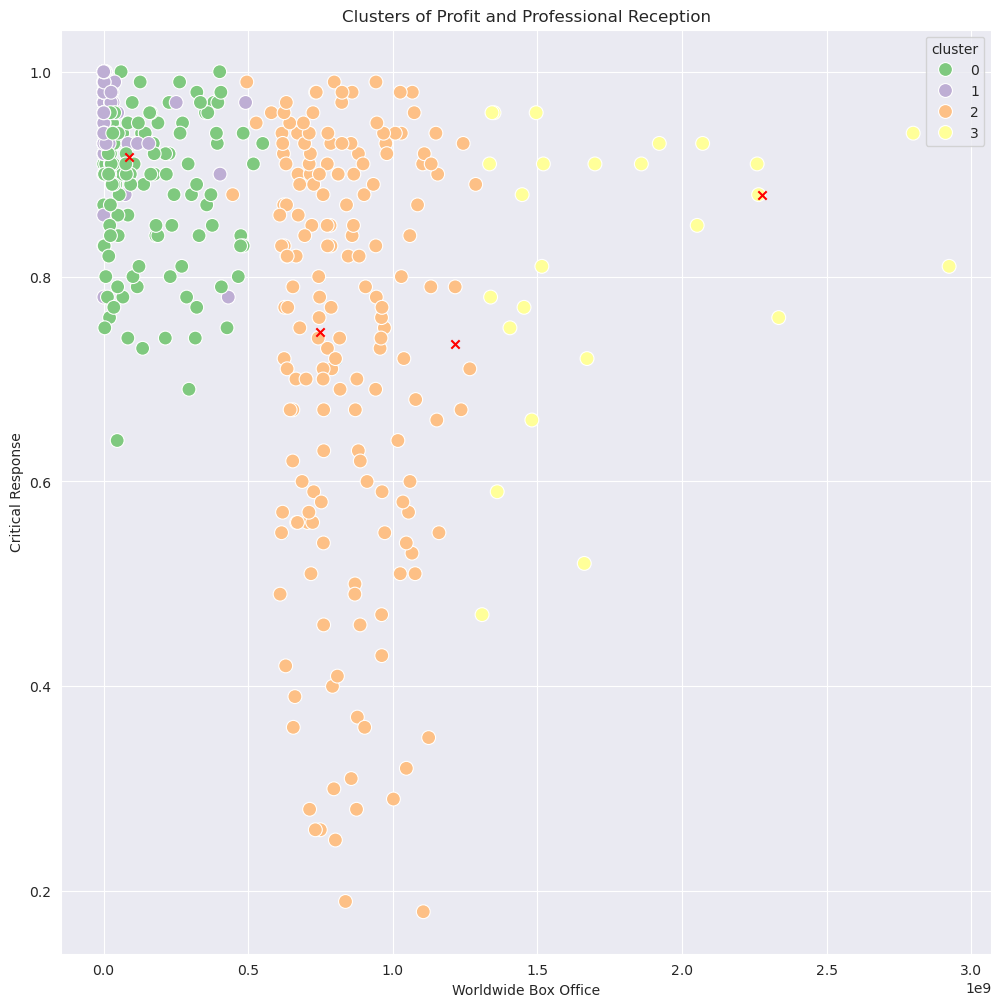

In [31]:
x1 = np.array(df['Worldwide Box Office'])
x2 = np.array(df['Critical Response'])
plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of Profit and Professional Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None', zorder = 5)

sns.scatterplot(x=df['Worldwide Box Office'], y=df['Critical Response'], hue=df['cluster'], palette='Accent', s=100, zorder = 10) 
plt.scatter(centers[:,0], centers[:,1], marker="x", color='r', zorder = 20)

plt.show()

##There is some overlap between low profit and high reception and lowest profit and highest reception. 

[[7.79800851e+07 9.30208333e-01]
 [1.11609483e+09 8.02058824e-01]
 [2.12660012e+09 8.83333333e-01]
 [6.99504161e+08 8.04172662e-01]]


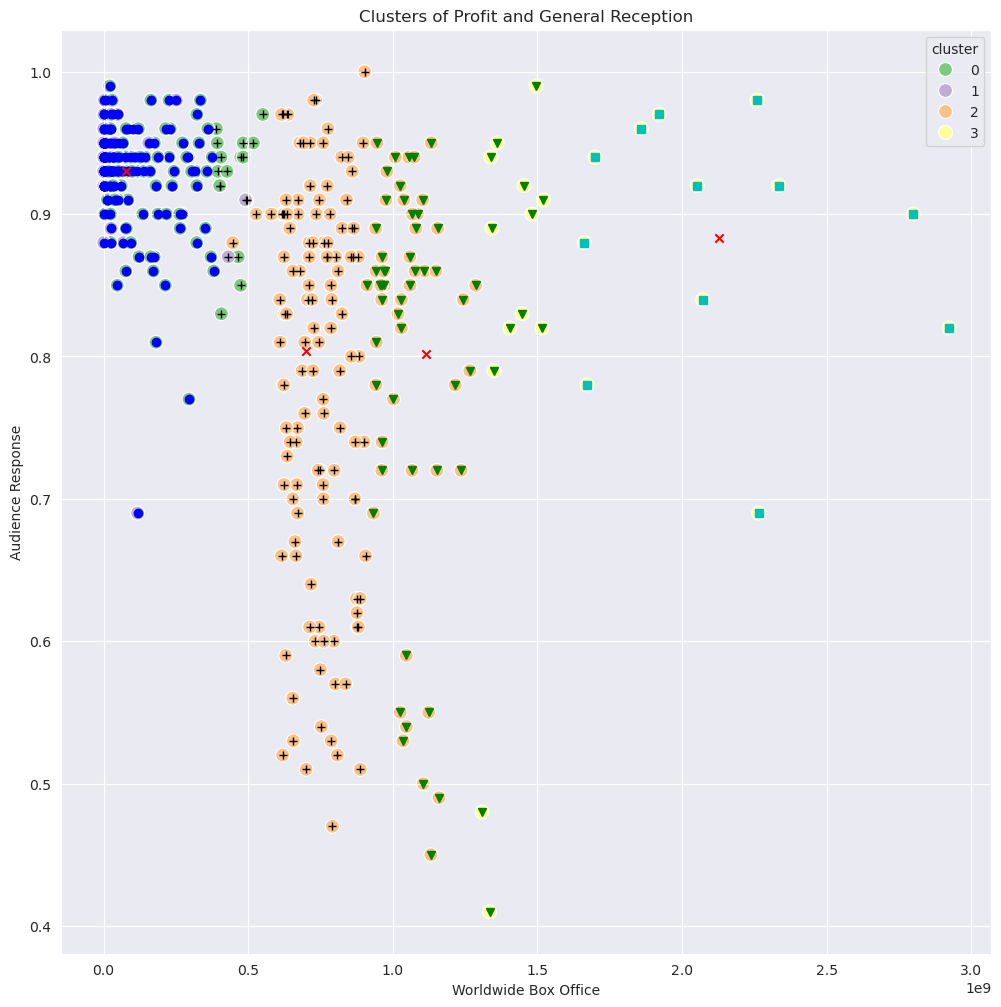

In [32]:
x1 = np.array(df['Worldwide Box Office'])
x2 = np.array(df['Audience Response'])
plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of Profit and General Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None', zorder = 5)

sns.scatterplot(x=df['Worldwide Box Office'], y=df['Audience Response'], hue=df['cluster'], palette='Accent', s=100, zorder = 0) 
plt.scatter(centers[:,0], centers[:,1], marker="x", color='r', zorder = 10)

plt.show()



[[0.92565611 0.94343891]
 [0.5909375  0.4028125 ]
 [0.75169811 0.64226415]
 [0.87809524 0.81580952]]


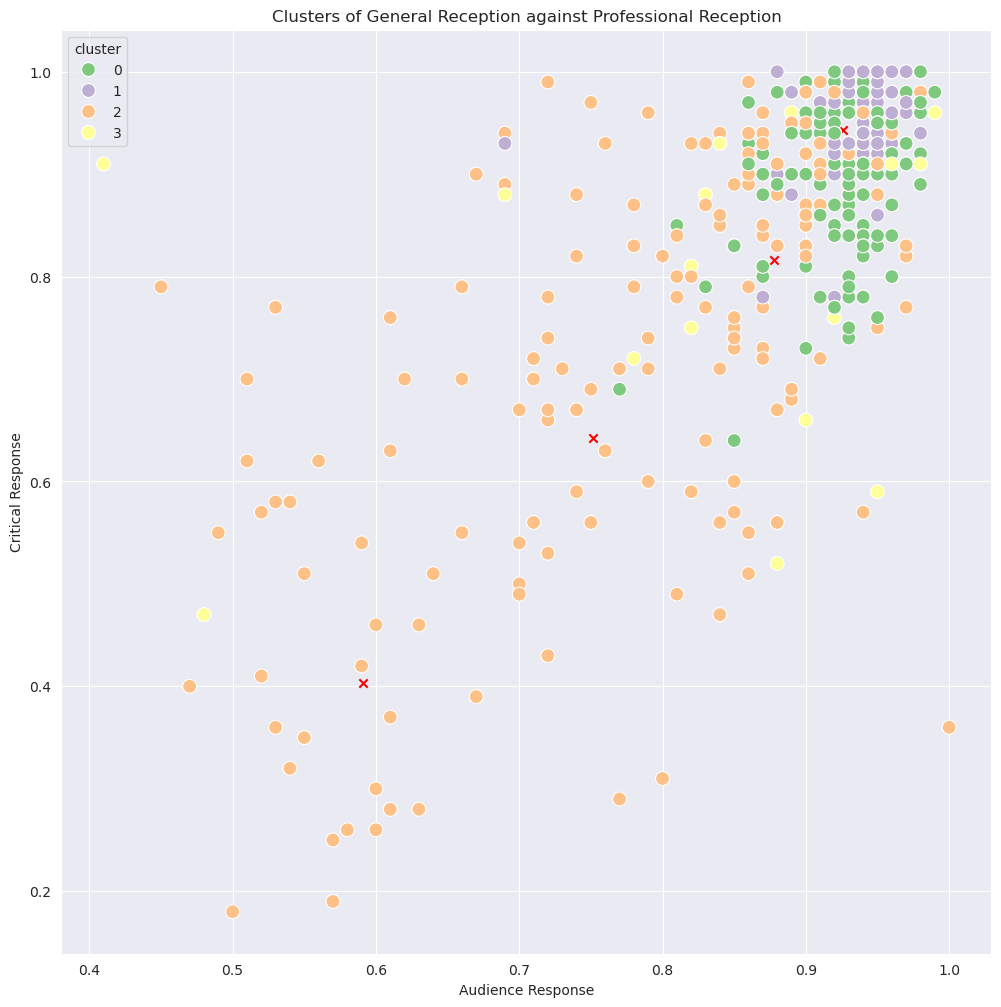

In [33]:
x1 = np.array(df['Audience Response'])
x2 = np.array(df['Critical Response'])
plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of General Reception against Professional Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None')

sns.scatterplot(x=df['Audience Response'], y=df['Critical Response'], hue=df['cluster'], palette='Accent', s=100, zorder=20) 
plt.scatter(centers[:,0], centers[:,1], marker="x", color='r', zorder = 10)

plt.show()

[[0.5909375  0.4028125 ]
 [0.87809524 0.81580952]
 [0.92565611 0.94343891]
 [0.75169811 0.64226415]]


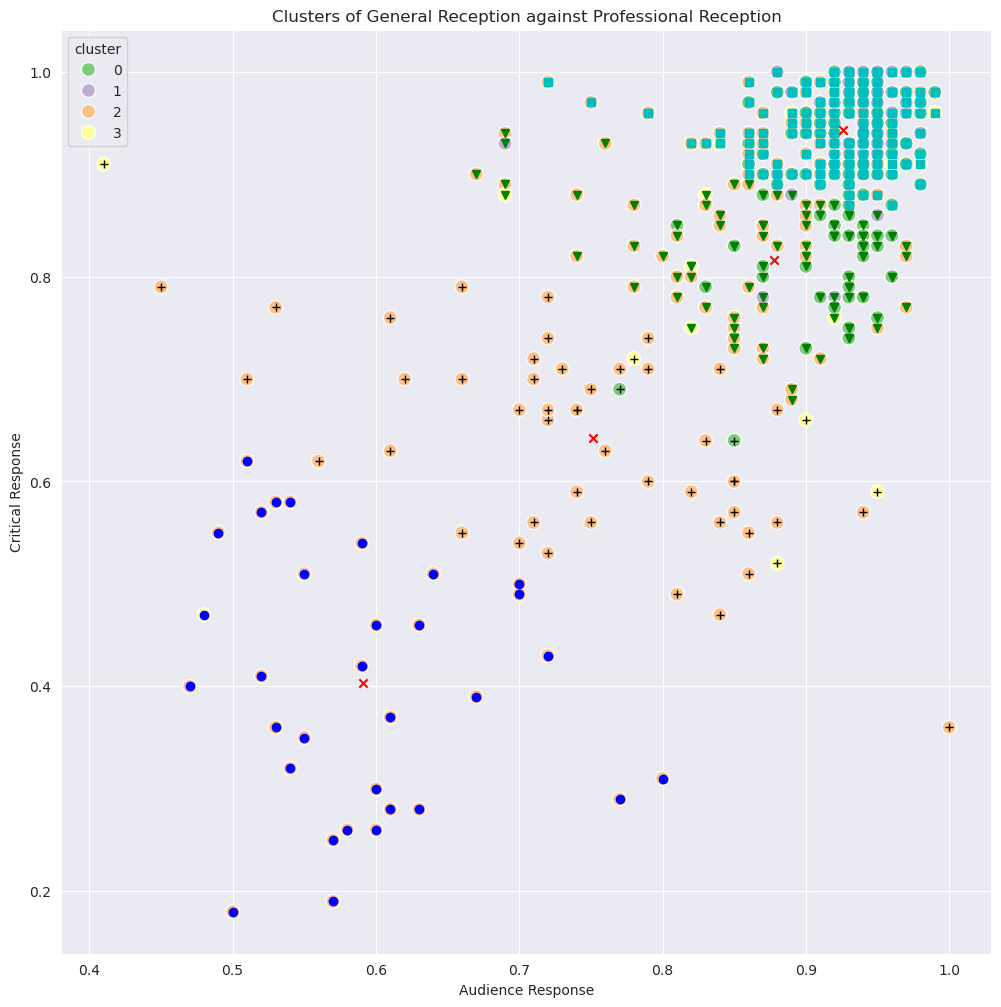

In [34]:
x1 = np.array(df['Audience Response'])
x2 = np.array(df['Critical Response'])
plt.figure(figsize=(12,12))
# create new plot and data
plt.plot()
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
colors = ['b', 'g', 'c', 'black']
markers = ['o', 'v', 's', '+']

# KMeans algorithm 
K = 4
kmeans_model = KMeans(n_clusters=K).fit(X)

print(kmeans_model.cluster_centers_)
centers = np.array(kmeans_model.cluster_centers_)

plt.plot()
plt.title('Clusters of General Reception against Professional Reception')

for i, l in enumerate(kmeans_model.labels_):
    plt.plot(x1[i], x2[i], color=colors[l], marker=markers[l],ls='None')

sns.scatterplot(x=df['Audience Response'], y=df['Critical Response'], hue=df['cluster'], palette='Accent', s=100) 
plt.scatter(centers[:,0], centers[:,1], marker="x", color='r', zorder = 10)

plt.show()

[Text(0.5555555555555556, 0.9166666666666666, 'Worldwide Box Office <= 564894560.0\ngini = 0.669\nsamples = 411\nvalue = [137, 72, 177, 25]'),
 Text(0.3333333333333333, 0.75, 'Year of Release <= 1977.0\ngini = 0.467\nsamples = 212\nvalue = [137, 72, 3, 0]'),
 Text(0.4444444444444444, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 72\nvalue = [0, 72, 0, 0]'),
 Text(0.4444444444444444, 0.5833333333333334, 'Worldwide Box Office <= 488673120.0\ngini = 0.042\nsamples = 140\nvalue = [137, 0, 3, 0]'),
 Text(0.2222222222222222, 0.4166666666666667, 'Worldwide Box Office <= 436327328.0\ngini = 0.015\nsamples = 136\nvalue = [135, 0, 1, 0]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 130\nvalue = [130, 0, 0, 0]'),
 Text(0.3333333333333333, 0.25, 'Worldwide Box Office <= 455790304.0\ngini = 0.278\nsamples = 6\nvalue = [5, 0, 1, 0]'),
 Text(0.2222222222222222, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0]'),
 Tex

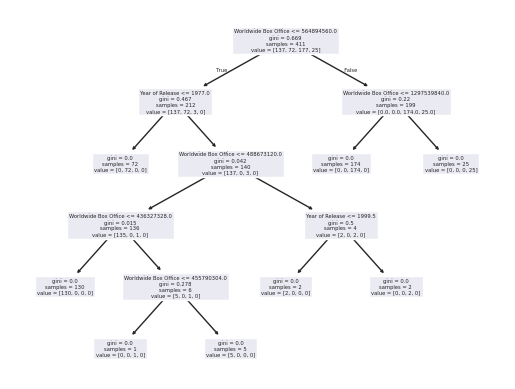

In [44]:
### Decision Trees ###
import pandas
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

features = ['Worldwide Box Office','Critical Response', 'Audience Response', 'Year of Release']
x = df[features]
y = df['cluster']
##I know this isn't allowed but it's the only one that works
#print(df)
#print(x)
#print(y)
##^Testing

dtree = DecisionTreeClassifier()
dtree = dtree.fit(x, y)
#plt.figure(figsize=(30,30))
tree.plot_tree(dtree, feature_names=features) 

## I absolutely need another variable to hold this tree down

In [ ]:
### Interpretation ###

There are four kinds of movies that are formed by the opinions of professional and general audiences. 
The first category are Minivan Movies, as represented by Cluster 0.
The second category are Classics, as represented by Cluster 1. 
The second category are Blockbusters, as represented by Cluster 2.
The last category are Genre Movies, as represented by Cluster 3. They are defined by above-average response and average profits, as they are made to be enjoying experiences for a specific audience.